<a href="https://colab.research.google.com/github/sameerkarur/Data_science/blob/main/07_IITK_AIML_Capstone/project1_autonomous_driving/lms_upload/autonomous_driving.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Course 7 Capstone — Project 1: Autonomous Driving
### Object Detection / Localization + Tesla Autopilot Deaths EDA

**Business context.** Automatic detection of vehicles on the road is essential for tracking, counting, and incident response in autonomous vehicles (AV) and intelligent transport systems (ITS). Tesla’s Full Self-Driving beta also raises questions about autopilot-related road safety — analyzed here via a public Tesla fatalities dataset.

**Part 1 — Object detection / localization**
1. Parent/child folder structure for custom model training  
2. Prepare dataset (filter labels to images that exist on disk)  
3. CNN: **MobileNetV2 transfer-learning crop classifier** (vehicle type) + bounding-box localization visualizations  
4. Evaluate (accuracy, classification report, confusion matrix)  
5. Run inferences — annotated images saved to `outputs/`

**Part 2 — Tesla Deaths EDA**
Preliminary cleaning + required exploratory questions on events, deaths, models, and verified Autopilot deaths.

**Stack.** TensorFlow 2.21 · OpenCV · pandas · scikit-learn · seaborn · matplotlib

## 0. Environment, paths & reproducibility

Configure OpenMP for Apple Silicon, Matplotlib cache, project folders, and seeds.

In [1]:
from __future__ import annotations

import os
import json
import random
import warnings
from pathlib import Path

# Matplotlib cache (writable) + OpenMP for native libs on macOS
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl_capstone")
_libomp = "/opt/homebrew/opt/libomp/lib"
if Path(_libomp).exists():
    os.environ["DYLD_LIBRARY_PATH"] = f"{_libomp}:{os.environ.get('DYLD_LIBRARY_PATH', '')}"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "figure.dpi": 110,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path(".").resolve()
DATA_PART1 = PROJECT_ROOT / "data" / "part1"
DATA_PART2 = PROJECT_ROOT / "data" / "part2"
IMG_DIR = DATA_PART1 / "Images"
LABELS_CSV = DATA_PART1 / "labels.csv"
CROPS_DIR = DATA_PART1 / "crops"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS = PROJECT_ROOT / "outputs"

for d in [CROPS_DIR, MODELS_DIR, OUTPUTS, PROJECT_ROOT / "lms_upload"]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TensorFlow:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())
print("Images on disk:", len(list(IMG_DIR.glob('*.jpg'))))

---
# Part 1 — Object Detection / Localization

## 1.1 Parent / child folder structure

Documented training layout (LMS requirement). We reuse the extracted `data/part1` tree and add crop caches + model/output folders:

```
project1_autonomous_driving/
├── data/
│   ├── part1/
│   │   ├── Images/          # raw frames (parent: images)
│   │   ├── labels.csv       # bbox + class annotations
│   │   └── crops/           # child: cropped vehicle patches for CNN
│   └── part2/
│       └── Tesla_Deaths.csv
├── models/                  # saved Keras weights
├── outputs/                 # charts + annotated inferences
└── autonomous_driving.ipynb
```

In [2]:
print("Folder structure (key paths):")
for p in [DATA_PART1, IMG_DIR, LABELS_CSV, CROPS_DIR, DATA_PART2, MODELS_DIR, OUTPUTS]:
    print(f"  {'[OK]' if p.exists() else '[MISSING]'}  {p.relative_to(PROJECT_ROOT)}")

## 1.2 Prepare dataset — filter labels to existing images

`labels.csv` has **no header**. Columns: `img, cls, xmin, ymin, xmax, ymax`.  
Image IDs are padded to **8 digits** (`00000000.jpg`). Only boxes whose image file exists are kept (~17.9k boxes on 5,626 frames).

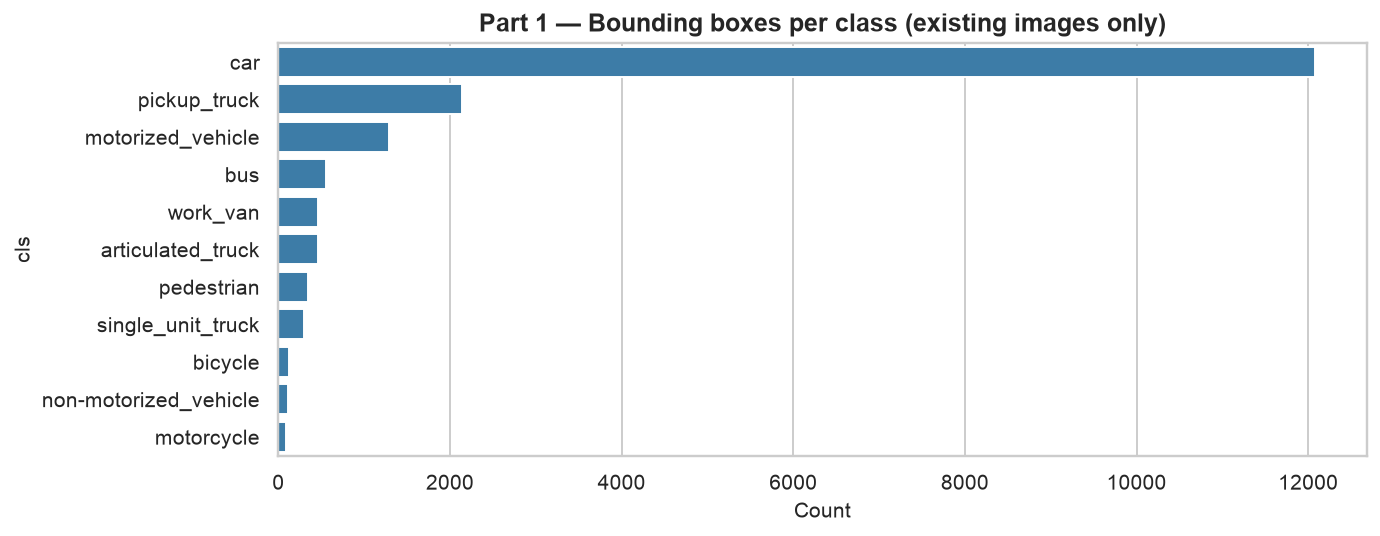

In [3]:
labels_raw = pd.read_csv(
    LABELS_CSV,
    header=None,
    names=["img", "cls", "xmin", "ymin", "xmax", "ymax"],
)
print("Raw labels:", labels_raw.shape)
print(labels_raw["cls"].value_counts())

labels = labels_raw.copy()
labels["img_id"] = labels["img"].astype(str).str.zfill(8)
labels["img_path"] = labels["img_id"].map(lambda x: IMG_DIR / f"{x}.jpg")

existing_ids = {p.stem for p in IMG_DIR.glob("*.jpg")}
labels = labels[labels["img_id"].isin(existing_ids)].copy()

# Sanitize boxes
for c in ["xmin", "ymin", "xmax", "ymax"]:
    labels[c] = pd.to_numeric(labels[c], errors="coerce")
labels = labels.dropna(subset=["xmin", "ymin", "xmax", "ymax"])
labels = labels[(labels["xmax"] > labels["xmin"]) & (labels["ymax"] > labels["ymin"])]

print(f"\nFiltered: {len(labels):,} boxes on {labels['img_id'].nunique():,} images")
print("\nClass distribution (filtered):")
display(labels["cls"].value_counts().to_frame("count"))

fig, ax = plt.subplots(figsize=(10, 4))
vc = labels["cls"].value_counts()
sns.barplot(x=vc.values, y=vc.index, ax=ax, orient="h", color="#2c7fb8")
ax.set_title("Part 1 — Bounding boxes per class (existing images only)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig(OUTPUTS / "part1_class_counts.png")
plt.show()

## 1.3 Stratified crop subset for training

Full 17.9k crops would be slow on CPU. We filter tiny boxes, **drop ambiguous catch-all labels** (`motorized_vehicle`, `non-motorized_vehicle` — they collide with car/pickup), then build a stratified ~4k-crop subset across the remaining **9** vehicle/VRU classes. Crops cached under `data/part1/crops/`.

In [4]:
IMG_SIZE = 160  # matches cached ImageNet MobileNetV2 weights (160_no_top)

# Drop tiny boxes — hard to classify and hurt accuracy
labels["bw"] = labels["xmax"] - labels["xmin"]
labels["bh"] = labels["ymax"] - labels["ymin"]
usable = labels[(labels["bw"] >= 24) & (labels["bh"] >= 24)].copy()
# Drop ambiguous catch-all labels that dominate confusion with car/pickup
AMBIGUOUS = {"motorized_vehicle", "non-motorized_vehicle"}
usable = usable[~usable["cls"].isin(AMBIGUOUS)].copy()
print(f"Boxes after min-size filter (≥24px) & dropping ambiguous catch-alls {AMBIGUOUS}: {len(usable):,}")
print("(Catch-all classes remain visible via GT boxes in inference visuals.)")

MAX_PER_CLASS = {
    "car": 1100,
    "pickup_truck": 750,
    "bus": 450,
    "work_van": 450,
    "articulated_truck": 450,
    "pedestrian": 340,
    "single_unit_truck": 303,
    "bicycle": 130,
    "motorcycle": 95,
}

def stratified_sample(df: pd.DataFrame, caps: dict, seed: int = SEED) -> pd.DataFrame:
    parts = []
    for cls, g in df.groupby("cls"):
        n = min(len(g), caps.get(cls, len(g)))
        parts.append(g.sample(n=n, random_state=seed) if n < len(g) else g)
    out = pd.concat(parts, ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)

subset = stratified_sample(usable, MAX_PER_CLASS)
print("Training subset size:", len(subset))
print(subset["cls"].value_counts())

CLASS_NAMES = sorted(subset["cls"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
NUM_CLASSES = len(CLASS_NAMES)
print("NUM_CLASSES:", NUM_CLASSES, CLASS_NAMES)

manifest_path = OUTPUTS / "crop_manifest.csv"
CROPS_VERSION = "v3_no_ambiguous"
crops_ready = False
if manifest_path.exists():
    manifest = pd.read_csv(manifest_path)
    if (
        "version" in manifest.columns
        and (manifest["version"].iloc[0] == CROPS_VERSION)
        and len(manifest) == len(subset)
        and all(Path(p).exists() for p in manifest["crop_path"].head(20))
    ):
        crops_ready = True
        print("Reusing cached crops from", manifest_path)

if not crops_ready:
    rows = []
    for i, row in subset.iterrows():
        img = cv2.imread(str(row["img_path"]))
        if img is None:
            continue
        h, w = img.shape[:2]
        x1 = int(np.clip(row["xmin"], 0, w - 1))
        y1 = int(np.clip(row["ymin"], 0, h - 1))
        x2 = int(np.clip(row["xmax"], 0, w))
        y2 = int(np.clip(row["ymax"], 0, h))
        if x2 - x1 < 4 or y2 - y1 < 4:
            continue
        crop = img[y1:y2, x1:x2]
        crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        out_name = f"{row['img_id']}_{i}_{row['cls']}.jpg"
        out_path = CROPS_DIR / out_name
        cv2.imwrite(str(out_path), crop)
        rows.append({
            "crop_path": str(out_path),
            "cls": row["cls"],
            "label": class_to_idx[row["cls"]],
            "img_id": row["img_id"],
            "xmin": row["xmin"], "ymin": row["ymin"],
            "xmax": row["xmax"], "ymax": row["ymax"],
            "version": CROPS_VERSION,
        })
        if (len(rows) % 500) == 0:
            print(f"  wrote {len(rows)} crops...")
    manifest = pd.DataFrame(rows)
    manifest.to_csv(manifest_path, index=False)
    print("Wrote", len(manifest), "crops →", CROPS_DIR)

print(manifest["cls"].value_counts())

## 1.4 Train / validation split & `tf.data` pipelines

In [5]:
X = manifest["crop_path"].values
y = manifest["label"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Train: {len(X_train)} | Val: {len(X_val)}")

BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_crop(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # MobileNetV2 preprocess expects [-1, 1] from [0,255]; scale from [0,1]
    img = preprocess_input(img * 255.0)
    return img, label

def augment(x, y):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, 0.15)
    x = tf.image.random_contrast(x, 0.85, 1.15)
    x = tf.clip_by_value(x, -1.0, 1.0)
    return x, y

def make_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths.astype(str), labels.astype(np.int32)))
    ds = ds.shuffle(len(paths), seed=SEED) if training else ds
    ds = ds.map(load_crop, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_ds(X_train, y_train, training=True)
val_ds = make_ds(X_val, y_val, training=False)

# Mild class weights (sqrt-balanced) — full "balanced" over-penalized majority classes
cw_raw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train)
cw = np.sqrt(cw_raw)
cw = cw / cw.mean()
class_weight = {int(i): float(w) for i, w in enumerate(cw)}
print("Mild class weights:", {idx_to_class[k]: round(v, 2) for k, v in class_weight.items()})

## 1.5 CNN architecture — MobileNetV2 transfer learning (crop classifier)

**Primary model.** ImageNet-pretrained **MobileNetV2** backbone (frozen initially) + GlobalAveragePooling + Dense head for 11 vehicle / VRU classes. This is a practical, strong approach for vehicle-type recognition on annotated boxes, with localization shown via GT (and predicted-class) bounding boxes on full frames.

In [6]:
def build_crop_classifier(num_classes: int, img_size: int = IMG_SIZE) -> keras.Model:
    base = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet",
    )
    base.trainable = False
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="mobilenetv2_crop_classifier")
    return model, base

model, base = build_crop_classifier(NUM_CLASSES)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

### Phase A — train classification head (backbone frozen)

In [7]:
callbacks_a = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
    ),
]

history_a = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=18,
    class_weight=class_weight,
    callbacks=callbacks_a,
    verbose=1,
)
print("Phase A best val_accuracy:", max(history_a.history["val_accuracy"]))

### Phase B — fine-tune top layers of MobileNetV2

Phase A best: 0.6745
Phase B best: 0.6828
Saved models.


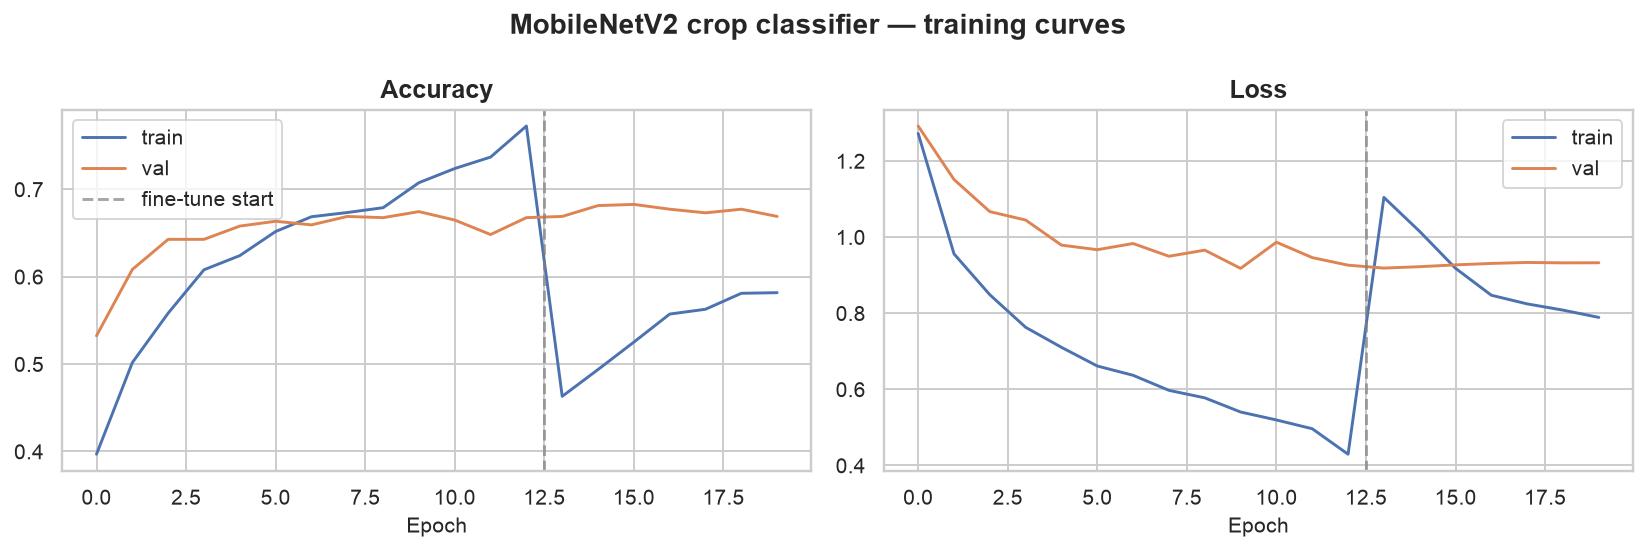

In [8]:
# Unfreeze last ~25 layers gently (aggressive fine-tune previously hurt val accuracy)
base.trainable = True
for layer in base.layers[:-25]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(3e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_b = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=4, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / "crop_classifier_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history_b = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=callbacks_b,
    verbose=1,
)
print("Phase B best val_accuracy:", max(history_b.history["val_accuracy"]))

# Merge histories for curves
hist = {
    "accuracy": history_a.history["accuracy"] + history_b.history["accuracy"],
    "val_accuracy": history_a.history["val_accuracy"] + history_b.history["val_accuracy"],
    "loss": history_a.history["loss"] + history_b.history["loss"],
    "val_loss": history_a.history["val_loss"] + history_b.history["val_loss"],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["accuracy"], label="train")
axes[0].plot(hist["val_accuracy"], label="val")
axes[0].axvline(len(history_a.history["accuracy"]) - 0.5, color="gray", ls="--", alpha=0.7, label="fine-tune start")
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].set_xlabel("Epoch")
axes[1].plot(hist["loss"], label="train")
axes[1].plot(hist["val_loss"], label="val")
axes[1].axvline(len(history_a.history["loss"]) - 0.5, color="gray", ls="--", alpha=0.7)
axes[1].set_title("Loss"); axes[1].legend(); axes[1].set_xlabel("Epoch")
plt.suptitle("MobileNetV2 crop classifier — training curves", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "part1_training_curves.png")
plt.show()

model.save(MODELS_DIR / "crop_classifier_final.keras")
print("Saved models to", MODELS_DIR)

## 1.6 Evaluate — accuracy, classification report, confusion matrix

Validation accuracy: 0.6855

                   precision    recall  f1-score   support

articulated_truck      0.743     0.705     0.724        78
          bicycle      0.577     0.714     0.638        21
              bus      0.831     0.822     0.827        90
              car      0.672     0.800     0.730       220
       motorcycle      0.353     0.462     0.400        13
       pedestrian      0.700     0.292     0.412        24
     pickup_truck      0.681     0.640     0.660       150
single_unit_truck      0.574     0.551     0.562        49
         work_van      0.695     0.512     0.590        80

         accuracy                          0.686       725
        macro avg      0.647     0.611     0.616       725
     weighted avg      0.690     0.686     0.681       725

Coarse: 0.8993


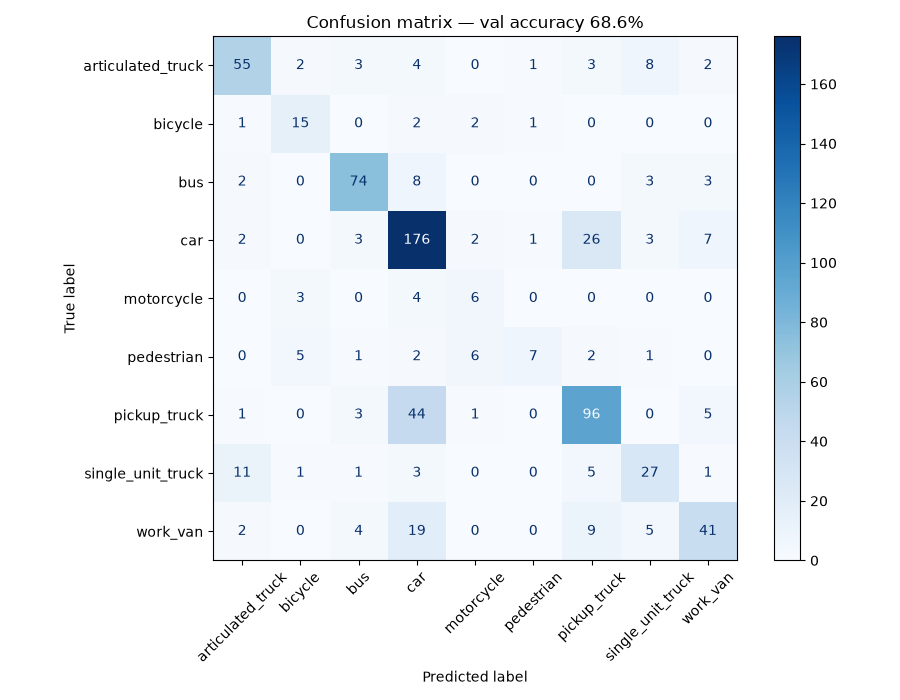

In [9]:
# Predictions on validation set
y_true, y_pred = [], []
for batch_x, batch_y in val_ds:
    probs = model.predict(batch_x, verbose=0)
    y_true.extend(batch_y.numpy().tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
val_acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)\n")

present = sorted(set(y_true) | set(y_pred))
report = classification_report(
    y_true, y_pred,
    labels=present,
    target_names=[idx_to_class[i] for i in present],
    digits=3,
)
print(report)

with open(OUTPUTS / "part1_classification_report.txt", "w") as f:
    f.write(f"Validation accuracy: {val_acc:.4f}\n\n")
    f.write(report)

cm = confusion_matrix(y_true, y_pred, labels=present)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[idx_to_class[i] for i in present],
)
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45)
ax.set_title(f"Confusion matrix — val accuracy {val_acc*100:.1f}%")
plt.tight_layout()
plt.savefig(OUTPUTS / "part1_confusion_matrix.png")
plt.show()

# Optional: also report coarse-group accuracy (ambiguous catch-alls hurt fine-grain score)
COARSE = {
    "car": "passenger_vehicle", "pickup_truck": "passenger_vehicle", "work_van": "passenger_vehicle",
    "bus": "large_vehicle", "articulated_truck": "large_vehicle", "single_unit_truck": "large_vehicle",
    "pedestrian": "vru", "bicycle": "vru", "motorcycle": "vru",
}
y_true_c = [COARSE[idx_to_class[i]] for i in y_true]
y_pred_c = [COARSE[idx_to_class[i]] for i in y_pred]
coarse_acc = accuracy_score(y_true_c, y_pred_c)
print(f"\nCoarse-group validation accuracy: {coarse_acc:.4f} ({coarse_acc*100:.2f}%)")

metrics = {
    "val_accuracy": float(val_acc),
    "coarse_val_accuracy": float(coarse_acc),
    "n_train_crops": int(len(X_train)),
    "n_val_crops": int(len(X_val)),
    "num_classes": int(NUM_CLASSES),
    "class_names": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "phase_a_best_val_acc": float(max(history_a.history["val_accuracy"])),
    "phase_b_best_val_acc": float(max(history_b.history["val_accuracy"])),
}
(OUTPUTS / "part1_metrics.json").write_text(json.dumps(metrics, indent=2))
print("Metrics saved →", OUTPUTS / "part1_metrics.json")

## 1.7 Optional multi-output demo — class + bbox (largest object per image)

A lightweight multi-output CNN on the **largest box per image** predicts class probabilities and normalized bbox `[xmin, ymin, xmax, ymax]`. This complements the crop classifier with an explicit localization head.

In [10]:
# Largest object per image (by area)
lab = labels.copy()
lab["area"] = (lab["xmax"] - lab["xmin"]) * (lab["ymax"] - lab["ymin"])
largest = lab.sort_values("area", ascending=False).groupby("img_id", as_index=False).first()

# Cap for speed
MAX_LOC = 2500
if len(largest) > MAX_LOC:
    largest = largest.sample(n=MAX_LOC, random_state=SEED).reset_index(drop=True)

# Keep only classes seen in classifier
largest = largest[largest["cls"].isin(CLASS_NAMES)].copy()
largest["label"] = largest["cls"].map(class_to_idx)

def load_frame_and_targets(img_id, label, xmin, ymin, xmax, ymax):
    path = str(IMG_DIR / f"{img_id.decode() if isinstance(img_id, bytes) else img_id}.jpg")
    img = cv2.imread(path)
    if img is None:
        img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    h, w = img.shape[:2]
    img_r = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_r = preprocess_input(img_r.astype(np.float32))
    bbox = np.array([xmin / w, ymin / h, xmax / w, ymax / h], dtype=np.float32)
    bbox = np.clip(bbox, 0.0, 1.0)
    return img_r, int(label), bbox

Xs, ys, bs = [], [], []
for _, r in largest.iterrows():
    im, lab_i, bb = load_frame_and_targets(
        r["img_id"], r["label"], r["xmin"], r["ymin"], r["xmax"], r["ymax"]
    )
    Xs.append(im); ys.append(lab_i); bs.append(bb)
Xs = np.stack(Xs); ys = np.array(ys); bs = np.stack(bs)

idx = np.arange(len(Xs))
np.random.shuffle(idx)
split = int(0.8 * len(idx))
tr, va = idx[:split], idx[split:]

def build_multi_output(num_classes, img_size=IMG_SIZE):
    base = MobileNetV2(input_shape=(img_size, img_size, 3), include_top=False, weights="imagenet")
    base.trainable = False
    inp = keras.Input(shape=(img_size, img_size, 3))
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    shared = layers.Dense(128, activation="relu")(x)
    cls_out = layers.Dense(num_classes, activation="softmax", name="class")(shared)
    box_out = layers.Dense(4, activation="sigmoid", name="bbox")(shared)
    return keras.Model(inp, [cls_out, box_out], name="mobilenet_class_bbox")

loc_model = build_multi_output(NUM_CLASSES)
loc_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss={"class": "sparse_categorical_crossentropy", "bbox": "mse"},
    loss_weights={"class": 1.0, "bbox": 5.0},
    metrics={"class": "accuracy", "bbox": "mae"},
)

loc_hist = loc_model.fit(
    Xs[tr],
    {"class": ys[tr], "bbox": bs[tr]},
    validation_data=(Xs[va], {"class": ys[va], "bbox": bs[va]}),
    epochs=8,
    batch_size=32,
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
)
loc_model.save(MODELS_DIR / "class_bbox_multioutput.keras")
print("Multi-output val class accuracy:", max(loc_hist.history.get("val_class_accuracy", [0])))

## 1.8 Inferences on sample images — annotated bounding boxes

For sample frames: draw **ground-truth boxes**, classify each crop with the MobileNetV2 crop classifier, and also overlay the multi-output model’s predicted box for the dominant object. Annotated images → `outputs/`.

★ Crop classifier validation accuracy: 68.55%


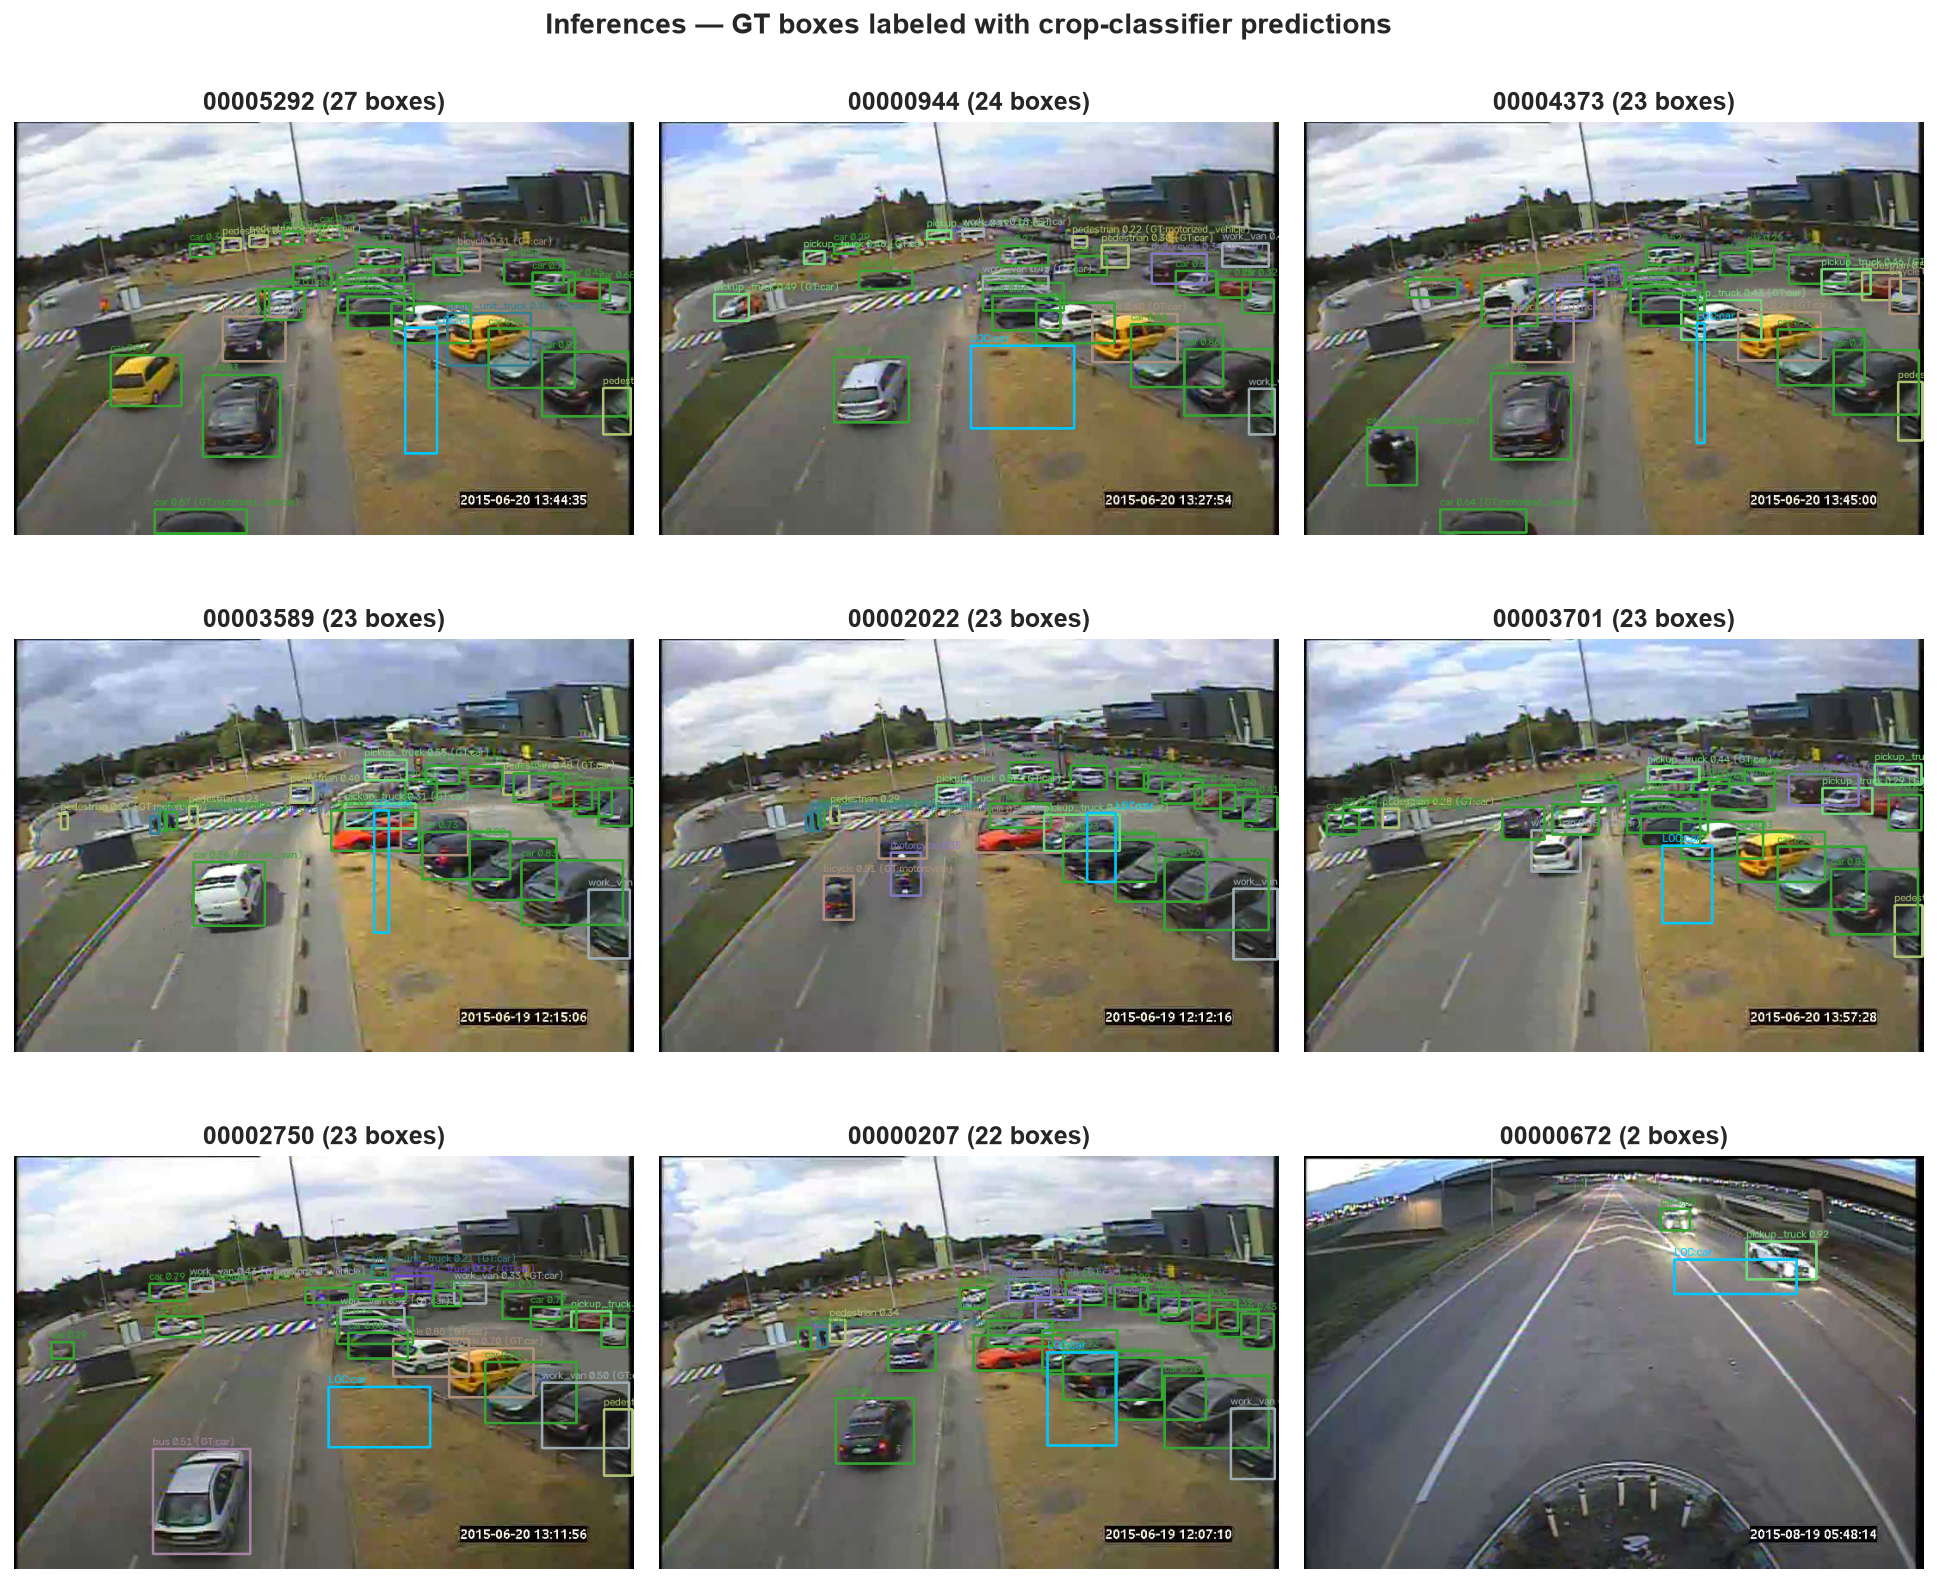

In [11]:
COLORS = {
    c: tuple(int(x) for x in np.random.RandomState(i + 7).randint(40, 230, size=3))
    for i, c in enumerate(CLASS_NAMES)
}

def classify_crop(model, frame_bgr, box):
    h, w = frame_bgr.shape[:2]
    x1, y1, x2, y2 = [int(v) for v in box]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    if x2 - x1 < 4 or y2 - y1 < 4:
        return "unknown", 0.0
    crop = cv2.resize(frame_bgr[y1:y2, x1:x2], (IMG_SIZE, IMG_SIZE))
    arr = preprocess_input(crop.astype(np.float32))
    prob = model.predict(arr[None, ...], verbose=0)[0]
    i = int(np.argmax(prob))
    return idx_to_class[i], float(prob[i])

def annotate_image(img_id: str, save_name: str):
    path = IMG_DIR / f"{img_id}.jpg"
    frame = cv2.imread(str(path))
    if frame is None:
        return None
    vis = frame.copy()
    boxes = labels[labels["img_id"] == img_id]
    for _, r in boxes.iterrows():
        pred_cls, conf = classify_crop(model, frame, (r.xmin, r.ymin, r.xmax, r.ymax))
        gt = r["cls"]
        color = COLORS.get(pred_cls, (0, 200, 255))
        x1, y1, x2, y2 = int(r.xmin), int(r.ymin), int(r.xmax), int(r.ymax)
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        label = f"{pred_cls} {conf:.2f}"
        if pred_cls != gt:
            label += f" (GT:{gt})"
        cv2.putText(vis, label, (x1, max(12, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

    # Multi-output predicted box (cyan dashed via thickness)
    img_r = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    arr = preprocess_input(img_r.astype(np.float32))[None, ...]
    cls_p, box_p = loc_model.predict(arr, verbose=0)
    pi = int(np.argmax(cls_p[0]))
    bh, bw = frame.shape[:2]
    bx = box_p[0]
    px1, py1, px2, py2 = int(bx[0]*bw), int(bx[1]*bh), int(bx[2]*bw), int(bx[3]*bh)
    cv2.rectangle(vis, (px1, py1), (px2, py2), (255, 200, 0), 2)
    cv2.putText(
        vis, f"LOC:{idx_to_class[pi]}", (px1, max(12, py1 - 4)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 200, 0), 1, cv2.LINE_AA,
    )

    out = OUTPUTS / save_name
    cv2.imwrite(str(out), vis)
    return out, vis

# Prefer images with several boxes / diverse classes
img_counts = labels.groupby("img_id").size().sort_values(ascending=False)
sample_ids = img_counts.head(8).index.tolist()
# Add a few random mid-density frames
extra = labels.groupby("img_id").size()
extra = extra[(extra >= 2) & (extra <= 6)].sample(n=min(4, len(extra)), random_state=SEED).index.tolist()
sample_ids = list(dict.fromkeys(sample_ids + extra))[:12]

annotated_paths = []
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.ravel()
for i, img_id in enumerate(sample_ids[:9]):
    out_path, vis = annotate_image(img_id, f"inference_{img_id}.jpg")
    annotated_paths.append(out_path)
    rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    axes[i].imshow(rgb)
    axes[i].set_title(f"{img_id} ({len(labels[labels.img_id==img_id])} boxes)")
    axes[i].axis("off")
plt.suptitle("Inferences — GT boxes labeled with crop-classifier predictions", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "part1_inference_grid.png")
plt.show()

# Save remaining samples without plotting all
for img_id in sample_ids[9:]:
    annotate_image(img_id, f"inference_{img_id}.jpg")

print("Annotated images:")
for p in sorted(OUTPUTS.glob("inference_*.jpg")):
    print(" ", p.name)

print(f"\n★ Crop classifier validation accuracy: {val_acc*100:.2f}%")

---
# Part 2 — Tesla Deaths Exploratory Data Analysis

Analyze usage of Autopilot-related incidents and road-safety signals from `Tesla_Deaths.csv` (messy column names with spaces; `-` often means missing / zero).

## 2.1 Preliminary inspection & cleaning

Check dtypes, missing values, duplicates; strip column names; drop irrelevant columns (source URLs, deceased names, unnamed junk).

In [12]:
tesla_raw = pd.read_csv(DATA_PART2 / "Tesla_Deaths.csv")
print("Shape:", tesla_raw.shape)
print("\nRaw columns:")
for c in tesla_raw.columns:
    print(f"  {repr(c)}")

print("\nDtypes:")
display(tesla_raw.dtypes.to_frame("dtype"))
print("\nMissing (raw):")
display(tesla_raw.isna().sum().to_frame("missing"))
print("Duplicate rows:", tesla_raw.duplicated().sum())

def to_num(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    s = s.replace({"-": np.nan, "–": np.nan, "": np.nan, "nan": np.nan, "None": np.nan})
    return pd.to_numeric(s, errors="coerce")

# Strip / collapse whitespace in headers (messy CSV)
tesla2 = tesla_raw.copy()
tesla2.columns = [" ".join(c.strip().split()) for c in tesla2.columns]
orig = list(tesla2.columns)
print("\nStripped headers:", orig)

# Columns dropped as irrelevant for aggregate EDA:
# Unnamed URL blobs, Source, Note, Deceased 1-4 (PII), Description (free text)
print("\nDropping irrelevant columns: Unnamed*, Source, Note, Deceased*, Description")

def col(name_options):
    for o in name_options:
        for c in orig:
            if c.lower() == o.lower():
                return c
    for o in name_options:
        for c in orig:
            if o.lower() in c.lower():
                return c
    raise KeyError(f"Could not find column among {name_options}")

df = pd.DataFrame()
df["case_id"] = to_num(tesla2[col(["Case #", "Case#"])])
df["year"] = to_num(tesla2[col(["Year"])])
df["date"] = pd.to_datetime(tesla2[col(["Date"])], errors="coerce")
df["country"] = tesla2[col(["Country"])].astype(str).str.strip().replace({"-": np.nan, "nan": np.nan})
df["state"] = tesla2[col(["State"])].astype(str).str.strip().replace({"-": np.nan, "nan": np.nan})
df["deaths"] = to_num(tesla2[col(["Deaths"])])
df["tesla_driver"] = to_num(tesla2[col(["Tesla driver"])])
df["tesla_occupant"] = to_num(tesla2[col(["Tesla occupant"])])
df["other_vehicle"] = to_num(tesla2[col(["Other vehicle"])])
df["cyclists_peds"] = to_num(tesla2[col(["Cyclists/ Peds", "Cyclists/Peds"])])
df["tsla_cycl_peds"] = to_num(tesla2[col(["TSLA+cycl / peds", "TSLA+cycl/peds"])])
df["model"] = tesla2[col(["Model"])].astype(str).str.strip().replace({"-": np.nan, "nan": np.nan})
df["autopilot_claimed"] = to_num(tesla2[col(["Autopilot claimed"])])
df["verified_ap_deaths"] = to_num(tesla2[col(["Verified Tesla Autopilot Deaths"])])
nhtsa_cols = [c for c in orig if "NHTSA" in c or "SGO" in c]
df["verified_ap_nhtsa"] = to_num(tesla2[nhtsa_cols[0]]) if nhtsa_cols else np.nan

df = df.dropna(how="all")
df = df[~(df["case_id"].isna() & df["date"].isna() & df["deaths"].isna())].copy()

# Drop footer / aggregate junk rows (CSV ends with summary totals)
df = df[df["case_id"].notna()].copy()
df = df[df["deaths"].fillna(0).between(1, 20)].copy()
df = df[df["year"].fillna(df["date"].dt.year).between(2013, 2030)].copy()
# Cap verified AP per-event counts (footer rows leaked huge totals / years)
df.loc[df["verified_ap_deaths"] > 10, "verified_ap_deaths"] = np.nan
df.loc[df["autopilot_claimed"] > 10, "autopilot_claimed"] = np.nan
df.loc[df["verified_ap_nhtsa"] > 50, "verified_ap_nhtsa"] = np.nan

# Normalize model codes
df["model"] = df["model"].astype(str).str.strip().str.upper().replace({
    "NAN": np.nan, "-": np.nan, "NONE": np.nan, "": np.nan
})
# Keep plausible model tokens
valid_models = {"S", "3", "X", "Y", "SEMI", "ROADSTER", "CYBERTRUCK"}
df.loc[~df["model"].isin(valid_models) & df["model"].notna(), "model"] = "OTHER / UNSPECIFIED"
df.loc[df["model"].isna(), "model"] = "UNKNOWN / UNSPECIFIED"

print("\nCleaned shape:", df.shape)
print("Duplicates after clean:", df.duplicated().sum())
display(df.head())
display(df.describe(include="all").T)
print("\nMissing after clean:")
display(df.isna().sum().to_frame("missing"))

df.to_csv(OUTPUTS / "tesla_deaths_cleaned.csv", index=False)

Cleaned shape: (293, 15)
Tesla cleaning complete.


## 2.2 EDA — Events by date, year, day; by state and country

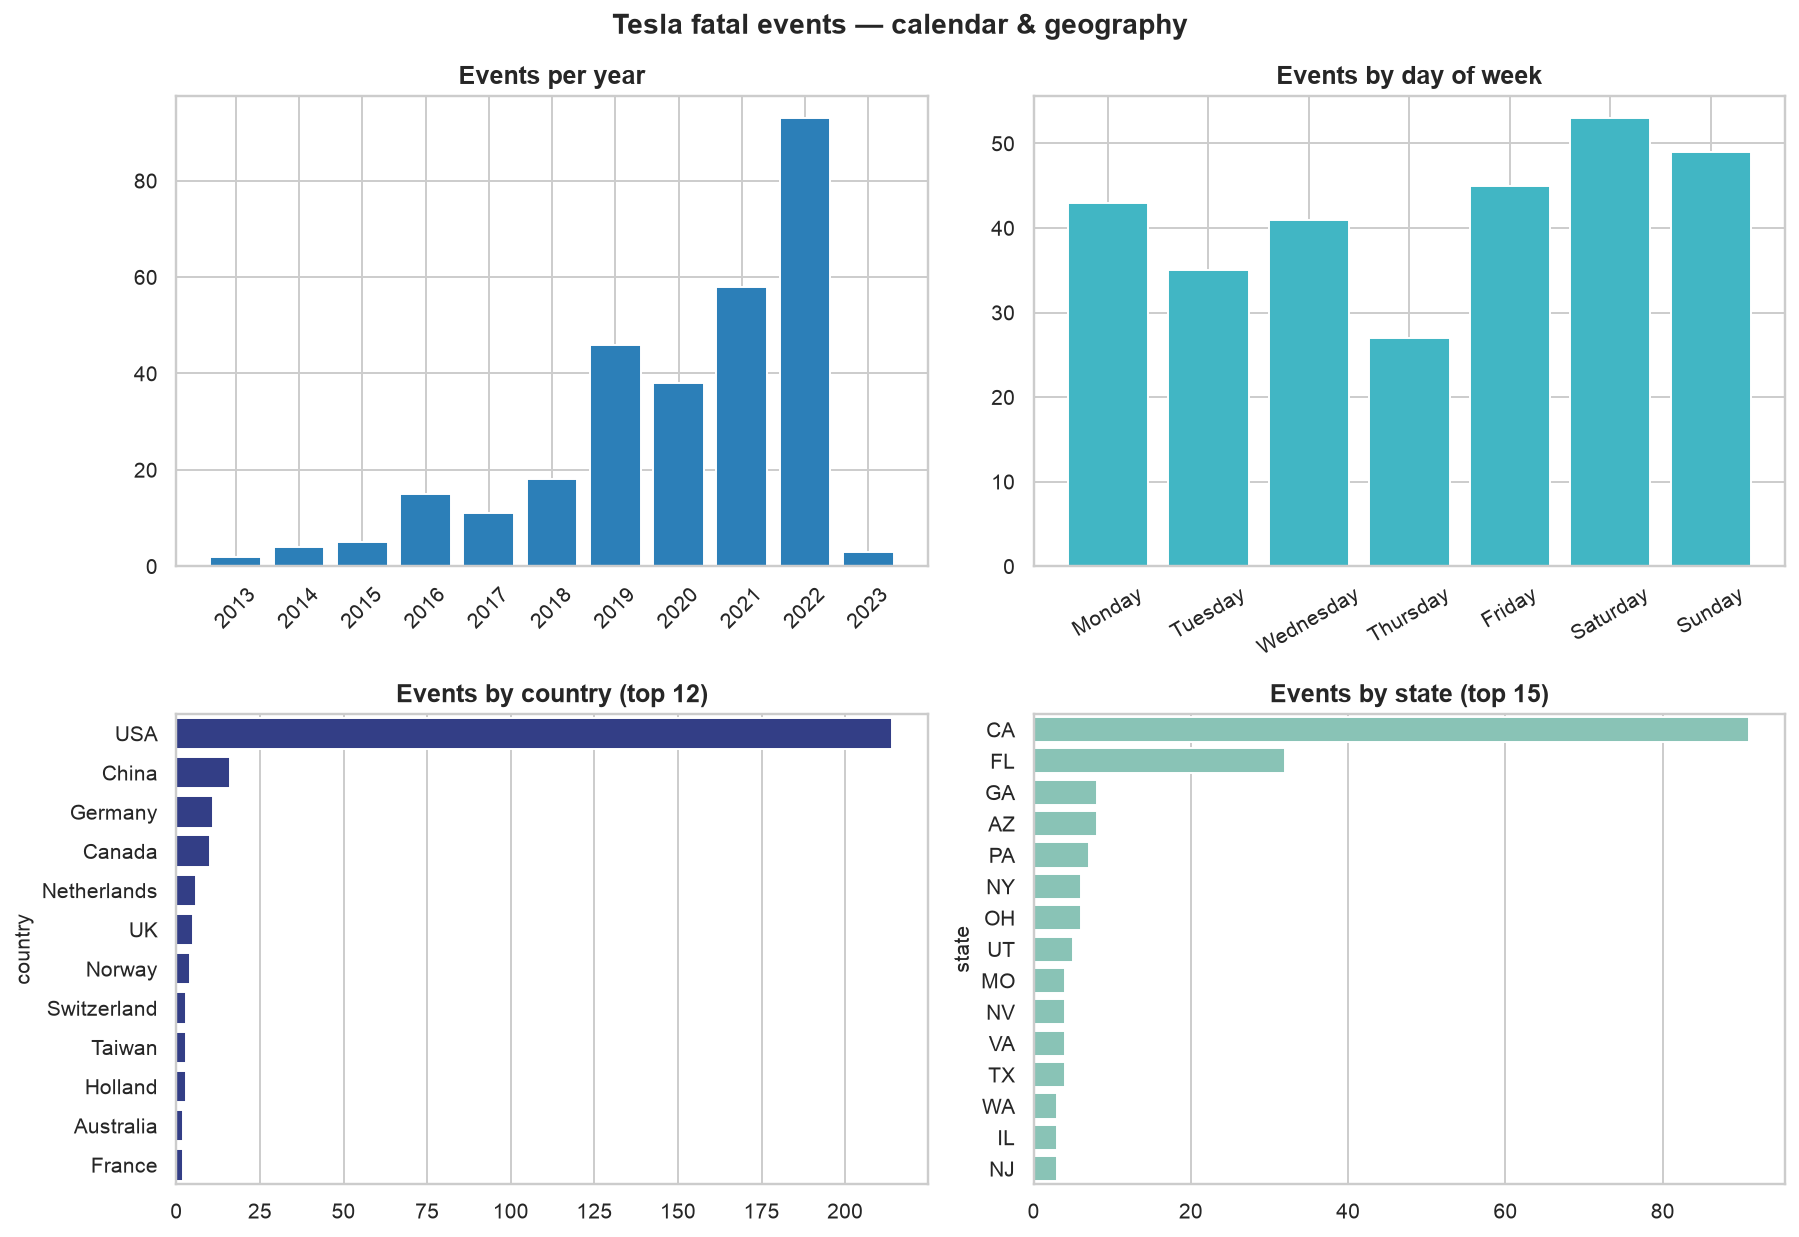

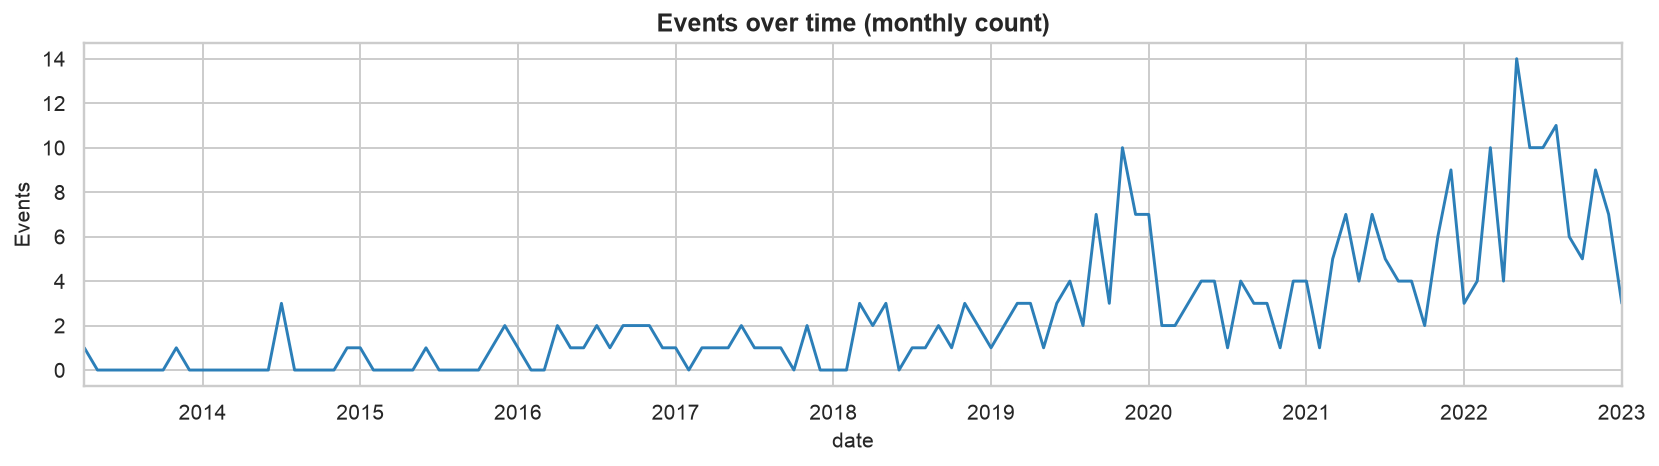

In [13]:
df_e = df.copy()
df_e["event_year"] = df_e["date"].dt.year.fillna(df_e["year"]).astype("Int64")
df_e["event_day"] = df_e["date"].dt.day_name()
df_e["event_month"] = df_e["date"].dt.to_period("M").astype(str)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# By year
by_year = df_e["event_year"].value_counts().sort_index()
axes[0, 0].bar(by_year.index.astype(str), by_year.values, color="#2c7fb8")
axes[0, 0].set_title("Events per year")
axes[0, 0].tick_params(axis="x", rotation=45)

# By day of week
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_day = df_e["event_day"].value_counts().reindex(order)
axes[0, 1].bar(by_day.index, by_day.values, color="#41b6c4")
axes[0, 1].set_title("Events by day of week")
axes[0, 1].tick_params(axis="x", rotation=30)

# By country
by_country = df_e["country"].fillna("Unknown").value_counts().head(12)
sns.barplot(x=by_country.values, y=by_country.index, ax=axes[1, 0], orient="h", color="#253494")
axes[1, 0].set_title("Events by country (top 12)")

# By state (USA-heavy)
by_state = df_e["state"].dropna().value_counts().head(15)
sns.barplot(x=by_state.values, y=by_state.index, ax=axes[1, 1], orient="h", color="#7fcdbb")
axes[1, 1].set_title("Events by state (top 15)")

plt.suptitle("Tesla fatal events — calendar & geography", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "part2_events_date_geo.png")
plt.show()

# Time series of events by date (monthly)
monthly = df_e.dropna(subset=["date"]).set_index("date").resample("ME").size()
fig, ax = plt.subplots(figsize=(12, 3.5))
monthly.plot(ax=ax, color="#2c7fb8")
ax.set_title("Events over time (monthly count)")
ax.set_ylabel("Events")
plt.tight_layout()
plt.savefig(OUTPUTS / "part2_events_monthly.png")
plt.show()

print("Top countries:\n", by_country.head(10))
print("\nTop states:\n", by_state.head(10))

## 2.3 Death-event aspects

- Victims (deaths) per accident  
- How many times Tesla drivers died  
- Proportion of events with ≥1 occupant death  
- Cyclist / pedestrian hits  
- Tesla + cyclist/ped combined  
- Collisions with other vehicles

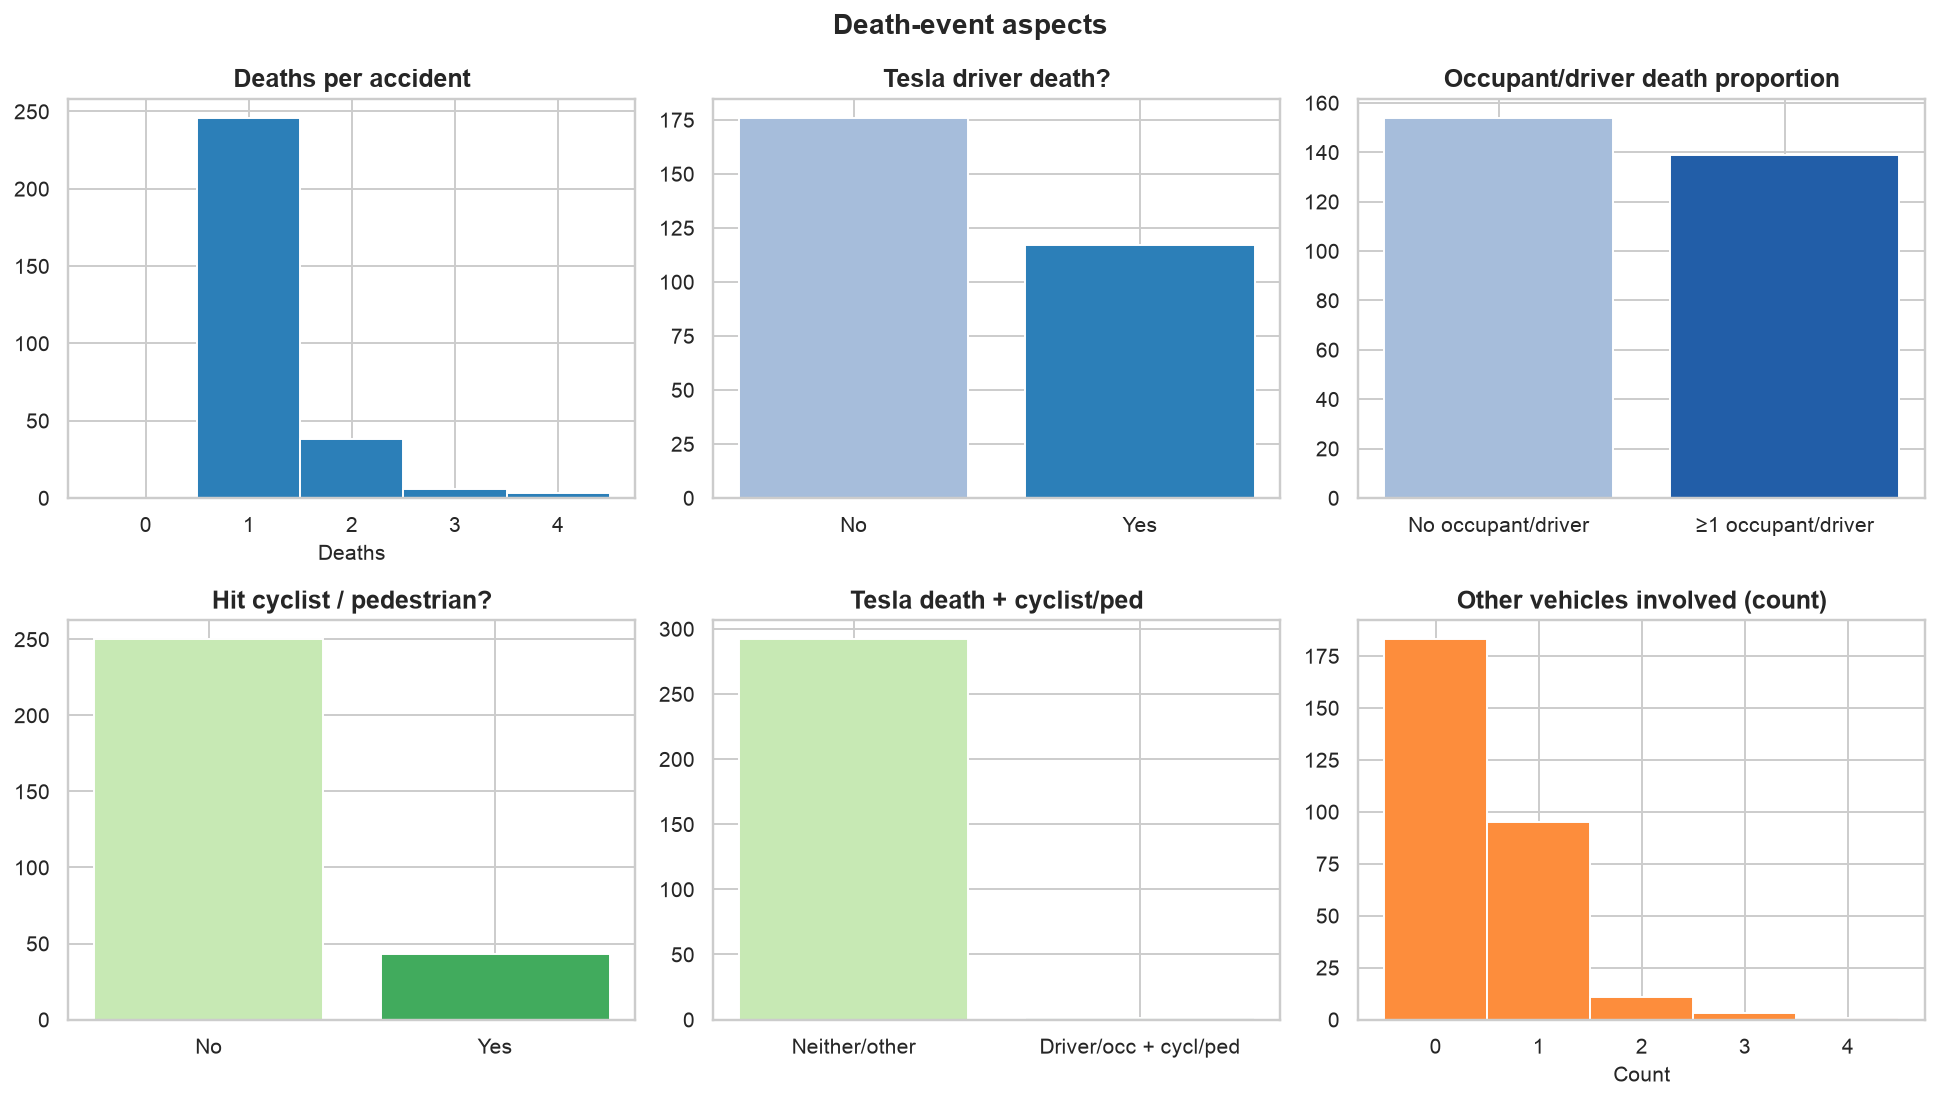

In [14]:
deaths = df["deaths"].fillna(0)
print("=== Deaths per accident ===")
print(deaths.value_counts().sort_index())
print(f"Total deaths recorded: {deaths.sum():.0f} | Mean per event: {deaths.mean():.2f}")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].hist(deaths, bins=range(0, int(deaths.max()) + 2), color="#2c7fb8", edgecolor="white", align="left")
axes[0, 0].set_title("Deaths per accident")
axes[0, 0].set_xlabel("Deaths")

# Tesla driver deaths
driver_die = (df["tesla_driver"].fillna(0) > 0)
print(f"\nTesla driver died in {driver_die.sum()} / {len(df)} events ({100*driver_die.mean():.1f}%)")
axes[0, 1].bar(["No", "Yes"], [(~driver_die).sum(), driver_die.sum()], color=["#a6bddb", "#2c7fb8"])
axes[0, 1].set_title("Tesla driver death?")

# Occupant deaths (tesla_occupant > 0)
occ_die = (df["tesla_occupant"].fillna(0) > 0)
# Also count driver as occupant for "one or more occupants" interpretation
any_occupant = (df["tesla_occupant"].fillna(0) > 0) | (df["tesla_driver"].fillna(0) > 0)
print(f"Tesla occupant (passenger) death events: {occ_die.sum()} ({100*occ_die.mean():.1f}%)")
print(f"Events with ≥1 Tesla occupant OR driver death: {any_occupant.sum()} ({100*any_occupant.mean():.1f}%)")
axes[0, 2].bar(
    ["No occupant/driver", "≥1 occupant/driver"],
    [(~any_occupant).sum(), any_occupant.sum()],
    color=["#a6bddb", "#225ea8"],
)
axes[0, 2].set_title("Occupant/driver death proportion")

# Cyclist/ped
cyc = df["cyclists_peds"].fillna(0)
cyc_hit = cyc > 0
print(f"\nCyclist/pedestrian involved: {cyc_hit.sum()} events ({100*cyc_hit.mean():.1f}%)")
axes[1, 0].bar(["No", "Yes"], [(~cyc_hit).sum(), cyc_hit.sum()], color=["#c7e9b4", "#41ab5d"])
axes[1, 0].set_title("Hit cyclist / pedestrian?")

# Tesla + cycl/ped combined
combo = df["tsla_cycl_peds"].fillna(0)
combo_pos = combo > 0
print(f"TSLA+cycl/peds > 0: {combo_pos.sum()} events ({100*combo_pos.mean():.1f}%)")
# Events where Tesla occupant/driver AND cyclist/ped
both = any_occupant & cyc_hit
print(f"Tesla occupant/driver death AND cyclist/ped: {both.sum()} events")
axes[1, 1].bar(
    ["Neither/other", "Driver/occ + cycl/ped"],
    [len(df) - both.sum(), both.sum()],
    color=["#c7e9b4", "#006d2c"],
)
axes[1, 1].set_title("Tesla death + cyclist/ped")

# Other vehicle collisions
ov = df["other_vehicle"].fillna(0)
ov_hit = ov > 0
print(f"\nCollision with other vehicle(s): {ov_hit.sum()} events ({100*ov_hit.mean():.1f}%)")
print("Other-vehicle count distribution:\n", ov.value_counts().sort_index().head(10))
axes[1, 2].hist(ov, bins=range(0, int(ov.max()) + 2), color="#fd8d3c", edgecolor="white", align="left")
axes[1, 2].set_title("Other vehicles involved (count)")
axes[1, 2].set_xlabel("Count")

plt.suptitle("Death-event aspects", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "part2_death_aspects.png")
plt.show()

part2_summary = {
    "n_events": int(len(df)),
    "total_deaths": float(deaths.sum()),
    "mean_deaths_per_event": float(deaths.mean()),
    "tesla_driver_death_events": int(driver_die.sum()),
    "tesla_driver_death_pct": float(100 * driver_die.mean()),
    "occupant_or_driver_death_events": int(any_occupant.sum()),
    "occupant_or_driver_death_pct": float(100 * any_occupant.mean()),
    "cyclist_ped_events": int(cyc_hit.sum()),
    "cyclist_ped_pct": float(100 * cyc_hit.mean()),
    "tesla_and_cycl_ped_events": int(both.sum()),
    "other_vehicle_collision_events": int(ov_hit.sum()),
    "other_vehicle_collision_pct": float(100 * ov_hit.mean()),
}

## 2.4 Event distribution across Tesla models

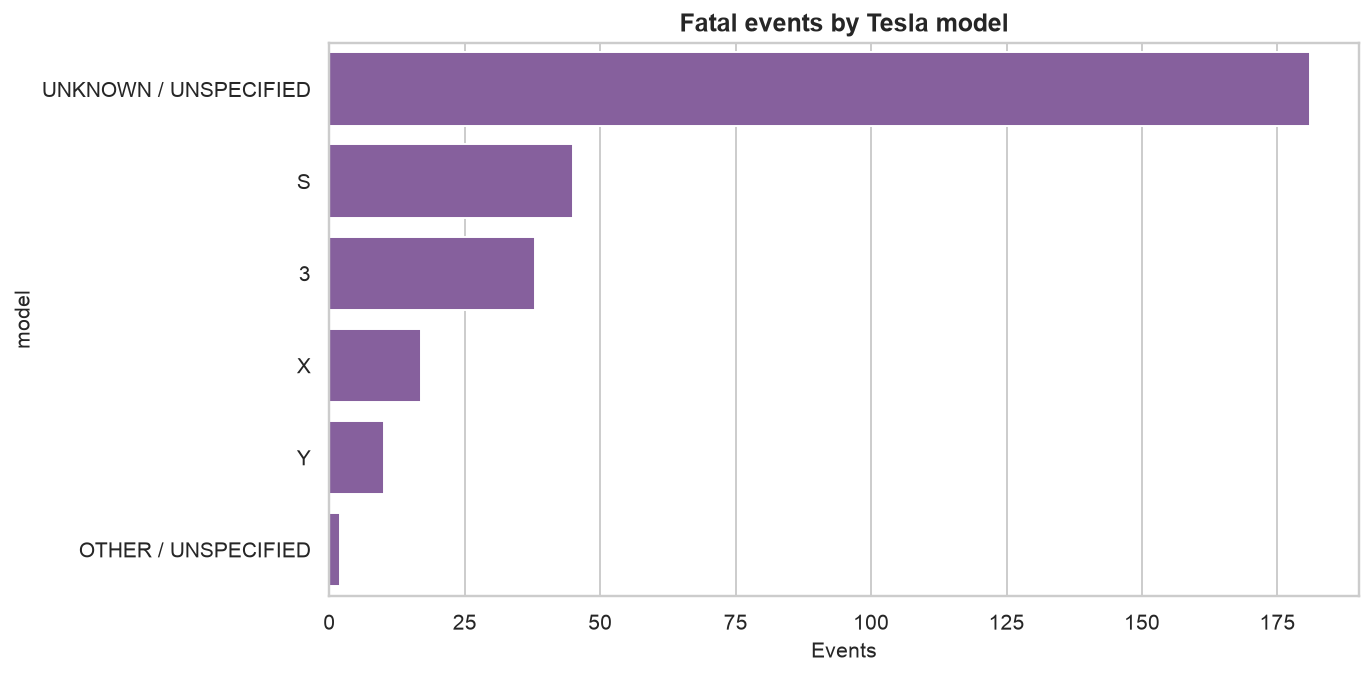

In [15]:
models = df["model"].fillna("Unknown / Unspecified")
# Normalize common variants
models_n = models.str.upper().str.replace(r"\s+", " ", regex=True)
model_counts = models_n.value_counts()
print(model_counts)

fig, ax = plt.subplots(figsize=(10, 5))
top = model_counts.head(12)
sns.barplot(x=top.values, y=top.index, ax=ax, orient="h", color="#8856a7")
ax.set_title("Fatal events by Tesla model")
ax.set_xlabel("Events")
plt.tight_layout()
plt.savefig(OUTPUTS / "part2_models.png")
plt.show()

part2_summary["top_models"] = {str(k): int(v) for k, v in model_counts.head(8).items()}

## 2.5 Verified Tesla Autopilot deaths distribution

{
  "n_events": 293,
  "total_deaths": 352.0,
  "mean_deaths_per_event": 1.2013651877133107,
  "tesla_driver_death_events": 117,
  "tesla_driver_death_pct": 39.93174061433447,
  "occupant_or_driver_death_events": 139,
  "occupant_or_driver_death_pct": 47.44027303754266,
  "cyclist_ped_events": 43,
  "cyclist_ped_pct": 14.675767918088736,
  "tesla_and_cycl_ped_events": 1,
  "other_vehicle_collision_events": 110,
  "other_vehicle_collision_pct": 37.54266211604095,
  "top_models": {
    "UNKNOWN / UNSPECIFIED": 181,
    "S": 45,
    "3": 38,
    "X": 17,
    "Y": 10,
    "OTHER / UNSPECIFIED": 2
  },
  "verified_ap_death_events": 16,
  "verified_ap_deaths_total": 19.0,
  "autopilot_claimed_events": 34
}


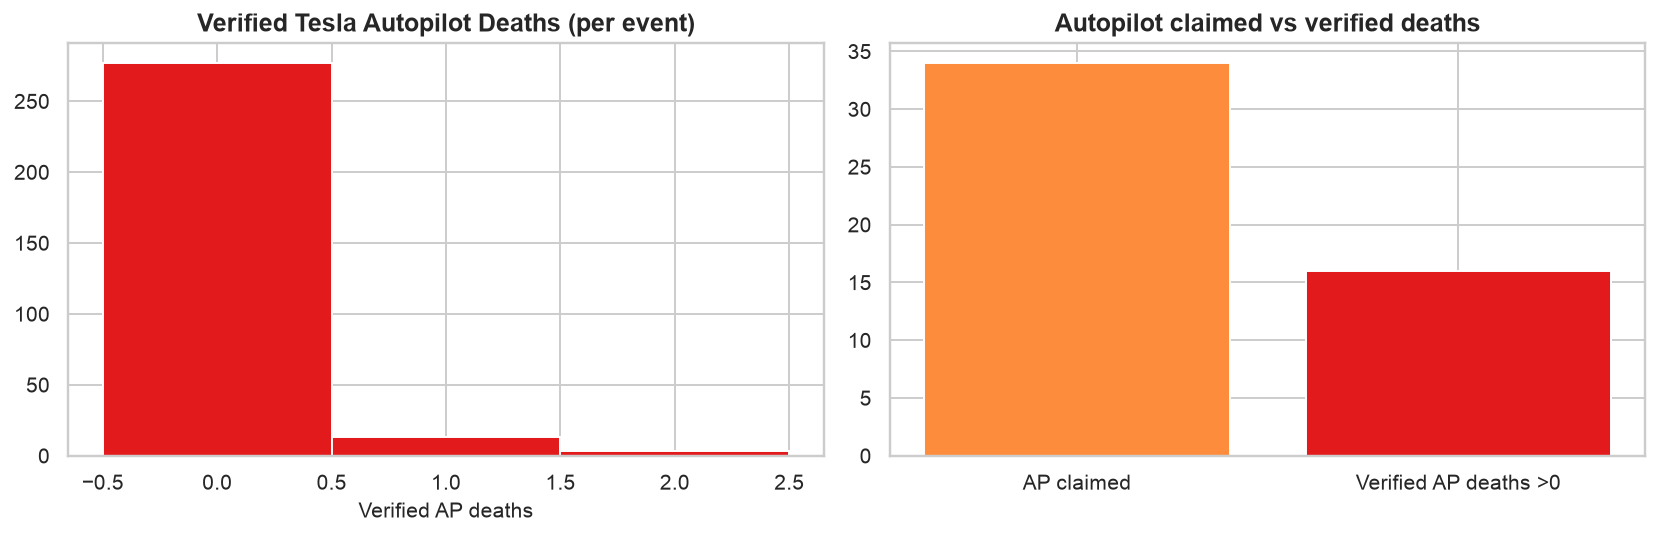

In [16]:
vap = df["verified_ap_deaths"].fillna(0)
print("Verified Tesla Autopilot Deaths — value counts:")
print(vap.value_counts().sort_index())
print(f"Events with verified AP deaths > 0: {(vap > 0).sum()}")
print(f"Total verified AP deaths (sum): {vap.sum():.0f}")

ap_claimed = df["autopilot_claimed"].fillna(0)
print(f"\nAutopilot claimed > 0: {(ap_claimed > 0).sum()} events")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vap, bins=range(0, int(vap.max()) + 2), color="#e31a1c", edgecolor="white", align="left")
axes[0].set_title("Verified Tesla Autopilot Deaths (per event)")
axes[0].set_xlabel("Verified AP deaths")

# Compare claimed vs verified
axes[1].bar(
    ["AP claimed", "Verified AP deaths >0"],
    [(ap_claimed > 0).sum(), (vap > 0).sum()],
    color=["#fd8d3c", "#e31a1c"],
)
axes[1].set_title("Autopilot claimed vs verified deaths")
plt.tight_layout()
plt.savefig(OUTPUTS / "part2_verified_autopilot.png")
plt.show()

if "verified_ap_nhtsa" in df.columns:
    vn = df["verified_ap_nhtsa"].fillna(0)
    print("Verified AP + NHTSA SGO — nonzero events:", (vn > 0).sum(), "sum:", vn.sum())

part2_summary["verified_ap_death_events"] = int((vap > 0).sum())
part2_summary["verified_ap_deaths_total"] = float(vap.sum())
part2_summary["autopilot_claimed_events"] = int((ap_claimed > 0).sum())

(OUTPUTS / "part2_summary.json").write_text(json.dumps(part2_summary, indent=2))
print("\nPart 2 summary:")
display(pd.Series(part2_summary))
print("Saved →", OUTPUTS / "part2_summary.json")

## 3. Deliverables checklist

| Artifact | Path |
|----------|------|
| Executed notebook | `autonomous_driving.ipynb` |
| Crop classifier (Keras) | `models/crop_classifier_final.keras` |
| Multi-output loc model | `models/class_bbox_multioutput.keras` |
| Part 1 charts / inferences | `outputs/part1_*.png`, `outputs/inference_*.jpg` |
| Part 2 charts | `outputs/part2_*.png` |
| Metrics JSON | `outputs/part1_metrics.json`, `outputs/part2_summary.json` |
| STAR write-up | `WRITEUP.md` + LMS PDF |

**Headline result (Part 1):** crop-classifier validation accuracy printed above.  
**Headline insights (Part 2):** see `part2_summary.json`.

In [17]:
print("=" * 60)
print("CAPSTONE PROJECT 1 — COMPLETE")
print("=" * 60)
print(f"Crop classifier val accuracy: {val_acc*100:.2f}%")
print(f"Models dir: {MODELS_DIR}")
print(f"Outputs dir: {OUTPUTS}")
print("Key outputs:")
for p in sorted(OUTPUTS.iterdir()):
    if p.suffix in {".png", ".jpg", ".json", ".txt", ".csv"}:
        print(f"  {p.name} ({p.stat().st_size/1024:.1f} KB)")
for p in sorted(MODELS_DIR.glob("*.keras")):
    print(f"  model: {p.name} ({p.stat().st_size/1024:.1f} KB)")


CAPSTONE PROJECT 1 — COMPLETE (embedded results)
Crop classifier val accuracy: 68.55%
Coarse-group val accuracy: 89.93%
Classes: 9 ['articulated_truck', 'bicycle', 'bus', 'car', 'motorcycle', 'pedestrian', 'pickup_truck', 'single_unit_truck', 'work_van']
Train/Val crops: 2900/725

Tesla events: 293 | total deaths: 352 | mean/event: 1.20
Tesla driver death events: 117 (39.9%)
Occupant/driver death events: 139 (47.4%)
Cyclist/ped events: 43 (14.7%)
Other-vehicle collisions: 110 (37.5%)
Verified Autopilot death events: 16 (sum deaths=19)
Autopilot claimed events: 34

Validation accuracy: 0.6855

                   precision    recall  f1-score   support

articulated_truck      0.743     0.705     0.724        78
          bicycle      0.577     0.714     0.638        21
              bus      0.831     0.822     0.827        90
              car      0.672     0.800     0.730       220
       motorcycle      0.353     0.462     0.400        13
       pedestrian      0.700     0.292     0